In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
DATA_PATH = "talabat_enhanced_orders2.csv"

df = pd.read_csv(DATA_PATH)

df.head(10)

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,56795,U4934,991,313,Sushi,5,305.65,2025-06-11 14:37:00,2025-06-11 14:58:00,21,...,Car,30.011739,31.220610,30.019520,31.196654,30.026240,31.200332,2.466822,Medium,Online
1,81167,U8701,151,316,Pizza,4,446.40,2025-06-08 20:13:00,2025-06-08 20:49:00,36,...,Car,30.045413,31.223939,30.062724,31.220663,30.050536,31.237185,1.944823,Low,Online
2,75889,U7689,138,363,Koshary,3,394.50,2025-06-07 03:29:00,2025-06-07 04:20:00,51,...,Car,31.057534,31.366192,31.045638,31.373109,31.020001,31.399328,1.475038,Low,Online
3,34786,U7076,540,258,Burger,4,139.20,2025-06-09 20:49:00,2025-06-09 21:30:00,41,...,Bicycle,30.787492,30.993809,30.789228,30.984042,30.805722,30.997262,0.954482,Low,Online
4,38475,U6245,847,110,Salad,2,207.02,2025-06-08 12:05:00,2025-06-08 12:33:00,28,...,Bicycle,30.803427,30.983386,30.768538,30.992124,30.792271,30.987854,3.957460,Medium,Online
5,88329,U3379,454,90,Sandwich,1,125.68,2025-06-02 04:02:00,2025-06-02 04:33:00,31,...,Car,31.180300,29.922967,31.180552,29.899449,31.211355,29.929651,2.242070,Low,Online
6,79499,U3029,168,479,Sushi,2,243.62,2025-06-15 01:06:00,2025-06-15 01:59:00,53,...,Motorbike,30.013826,31.215348,30.020233,31.228303,29.995995,31.212204,1.437552,Low,Online
7,27325,U3674,473,321,Fried Chicken,1,149.87,2025-06-04 01:02:00,2025-06-04 01:53:00,51,...,Car,30.794454,30.998586,30.791487,31.002607,30.799764,31.006845,0.506267,Low,Online
8,73621,U8696,704,42,Pasta,4,562.32,2025-06-14 06:45:00,2025-06-14 07:33:00,48,...,Car,30.573653,31.508104,30.602105,31.519432,30.587649,31.500689,3.336044,Low,Online
9,18180,U3260,458,183,Pasta,5,194.95,2025-06-03 02:50:00,2025-06-03 03:15:00,25,...,Motorbike,31.193297,29.906175,31.187237,29.913781,31.202042,29.926440,0.988472,Low,Online


The first rows confirm that the dataset loaded correctly. Each row represents one food delivery order, including information about the customer, restaurant, driver, and order outcome.

In [3]:
print("Shape:", df.shape)

print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (25000, 23)

Missing values per column:


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
missing_count,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


The dataset is clean because it has no missing values and no duplicate rows. Therefore, the focus of this lab will be feature engineering instead of data cleaning.

In [4]:
target_col = "Order_Status"
df[target_col].value_counts()

,count
Order_Status,
Delivered,10197
Cancelled,9812
In Transit,4991


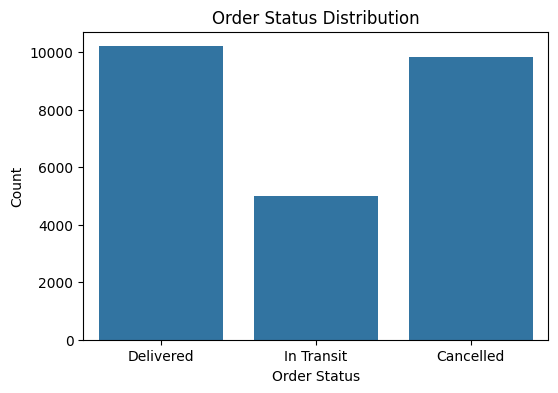

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

This graph shows the distribution of the target classes. It helps us understand whether the classes are balanced or imbalanced before training the model.

In [6]:
df.dtypes

,0
Order_ID,int64
User_ID,object
Restaurant_ID,int64
Driver_ID,int64
Item_Name,object
Quantity,int64
Total_Price,float64
Order_Time,object
Delivery_Time,object
Delivery_Duration_Minutes,int64


The dataset contains both numerical and categorical features. Numerical features include Quantity, Total_Price, and Delivery_Distance_km, while categorical features include City, Payment_Method, and Traffic_Level.

In [8]:
drop_cols = ["Delivery_Time", "Delivery_Duration_Minutes"]

drop_cols = [c for c in drop_cols if c in df.columns]

df = df.drop(columns=drop_cols)

df.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,City,Payment_Method,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,56795,U4934,991,313,Sushi,5,305.65,2025-06-11 14:37:00,Giza,Wallet,...,Car,30.011739,31.220610,30.019520,31.196654,30.026240,31.200332,2.466822,Medium,Online
1,81167,U8701,151,316,Pizza,4,446.40,2025-06-08 20:13:00,Cairo,Cash,...,Car,30.045413,31.223939,30.062724,31.220663,30.050536,31.237185,1.944823,Low,Online
2,75889,U7689,138,363,Koshary,3,394.50,2025-06-07 03:29:00,Mansoura,Credit Card,...,Car,31.057534,31.366192,31.045638,31.373109,31.020001,31.399328,1.475038,Low,Online
3,34786,U7076,540,258,Burger,4,139.20,2025-06-09 20:49:00,Tanta,Wallet,...,Bicycle,30.787492,30.993809,30.789228,30.984042,30.805722,30.997262,0.954482,Low,Online
4,38475,U6245,847,110,Salad,2,207.02,2025-06-08 12:05:00,Tanta,Credit Card,...,Bicycle,30.803427,30.983386,30.768538,30.992124,30.792271,30.987854,3.957460,Medium,Online


Delivery_Time and Delivery_Duration_Minutes were removed because they may cause data leakage. These features would not normally be available before predicting the final order status.

In [9]:
df_fe = df.copy()

df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")

df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([4, 5]).astype(int)
df_fe["is_peak_hour"] = df_fe["order_hour"].isin([12, 13, 14, 19, 20, 21]).astype(int)

df_fe[["Order_Time", "order_hour", "order_dayofweek", "is_weekend", "is_peak_hour"]].head(10)

,Order_Time,order_hour,order_dayofweek,is_weekend,is_peak_hour
0,2025-06-11 14:37:00,14,2,0,1
1,2025-06-08 20:13:00,20,6,0,1
2,2025-06-07 03:29:00,3,5,1,0
3,2025-06-09 20:49:00,20,0,0,1
4,2025-06-08 12:05:00,12,6,0,1
5,2025-06-02 04:02:00,4,0,0,0
6,2025-06-15 01:06:00,1,6,0,0
7,2025-06-04 01:02:00,1,2,0,0
8,2025-06-14 06:45:00,6,5,1,0
9,2025-06-03 02:50:00,2,1,0,0


Time-based features were created from Order_Time. These include the order hour, day of the week, weekend flag, and peak hour flag. These features may help the model understand ordering patterns.

In [10]:
df_fe["price_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]

df_fe[["Quantity", "Total_Price", "price_per_item"]].head(10)


,Quantity,Total_Price,price_per_item
0,5,305.65,61.13
1,4,446.40,111.60
2,3,394.50,131.50
3,4,139.20,34.80
4,2,207.02,103.51
5,1,125.68,125.68
6,2,243.62,121.81
7,1,149.87,149.87
8,4,562.32,140.58
9,5,194.95,38.99


A new feature called price_per_item was created by dividing Total_Price by Quantity. This feature may help the model distinguish between expensive and cheap orders.

In [11]:
df["Item_Name"].unique()

array(['Sushi', 'Pizza', 'Koshary', 'Burger', 'Salad', 'Sandwich',
       'Fried Chicken', 'Pasta', 'Shawarma'], dtype=object)

In [12]:
top_k = 10

top_items = df_fe["Item_Name"].value_counts().head(top_k).index

df_fe["Item_Name_reduced"] = np.where(
    df_fe["Item_Name"].isin(top_items),
    df_fe["Item_Name"],
    "Other"
)

df_fe["Item_Name_reduced"].value_counts()

,count
Item_Name_reduced,
Pizza,2859
Burger,2820
Koshary,2800
Pasta,2795
Shawarma,2788
Sandwich,2779
Sushi,2757
Fried Chicken,2721
Salad,2681


The Item_Name feature contains many unique values. To reduce complexity, only the top 10 most common item names were kept, while all other items were grouped into Other.

In [13]:
df_fe["price_tier"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 100, 250, 500, np.inf],
    labels=["low", "medium", "high", "very_high"]
)

df_fe[["Total_Price", "price_tier"]].head(10)

,Total_Price,price_tier
0,305.65,high
1,446.40,high
2,394.50,high
3,139.20,medium
4,207.02,medium
5,125.68,medium
6,243.62,medium
7,149.87,medium
8,562.32,very_high
9,194.95,medium


The Total_Price column was converted into price categories using binning. Orders were grouped into low, medium, high, and very high price tiers.


In [14]:
drop_cols = [
    "Order_ID",
    "User_ID",
    "Restaurant_ID",
    "Driver_ID",
    "Total_Price",
    "Order_Time",
    "Item_Name"
]

drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + ["Order_Status"])
y = df_fe["Order_Status"]

X.head()

,Quantity,City,Payment_Method,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,order_hour,order_dayofweek,is_weekend,is_peak_hour,price_per_item,Item_Name_reduced,price_tier
0,5,Giza,Wallet,Car,30.011739,31.220610,30.019520,31.196654,30.026240,31.200332,2.466822,Medium,Online,14,2,0,1,61.13,Sushi,high
1,4,Cairo,Cash,Car,30.045413,31.223939,30.062724,31.220663,30.050536,31.237185,1.944823,Low,Online,20,6,0,1,111.60,Pizza,high
2,3,Mansoura,Credit Card,Car,31.057534,31.366192,31.045638,31.373109,31.020001,31.399328,1.475038,Low,Online,3,5,1,0,131.50,Koshary,high
3,4,Tanta,Wallet,Bicycle,30.787492,30.993809,30.789228,30.984042,30.805722,30.997262,0.954482,Low,Online,20,0,0,1,34.80,Burger,medium
4,2,Tanta,Credit Card,Bicycle,30.803427,30.983386,30.768538,30.992124,30.792271,30.987854,3.957460,Medium,Online,12,6,0,1,103.51,Salad,medium


The feature matrix X contains the input features, while y contains the target variable Order_Status.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (20000, 20)
Test size: (5000, 20)


The dataset was divided into training and testing sets. 80% of the data was used for training and 20% was used for testing.

In [17]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumeric columns:")
print(numeric_cols)

Categorical columns:
['City', 'Payment_Method', 'Driver_Vehicle', 'Traffic_Level', 'Driver_Availability', 'Item_Name_reduced', 'price_tier']

Numeric columns:
['Quantity', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'order_hour', 'order_dayofweek', 'is_weekend', 'is_peak_hour', 'price_per_item']


In [19]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [20]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.392

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.38      0.45      0.41      1963
   Delivered       0.40      0.52      0.46      2039
  In Transit       0.23      0.01      0.02       998

    accuracy                           0.39      5000
   macro avg       0.34      0.33      0.30      5000
weighted avg       0.36      0.39      0.35      5000



The Random Forest model was trained using the engineered features. Accuracy and the classification report were used to evaluate the model performance.

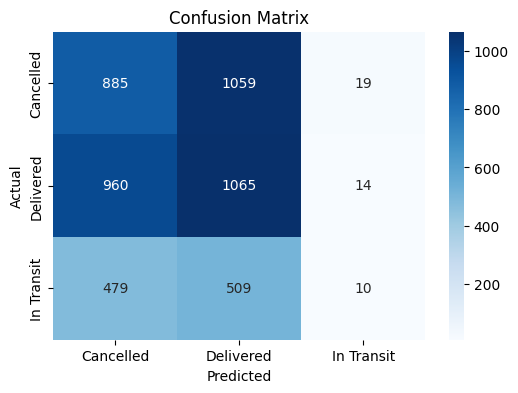

In [21]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
ohe = model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]

cat_feature_names = ohe.get_feature_names_out(categorical_cols)

all_feature_names = numeric_cols + list(cat_feature_names)

importances = model.named_steps["classifier"].feature_importances_

fi = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

fi.head(15)

,feature,importance
12,price_per_item,0.079796
7,Delivery_Distance_km,0.079433
6,Driver_Lon,0.078048
5,Driver_Lat,0.077838
4,Customer_Lon,0.077476
1,Restaurant_Lat,0.077260
3,Customer_Lat,0.077141
2,Restaurant_Lon,0.076829
8,order_hour,0.053811
9,order_dayofweek,0.039705


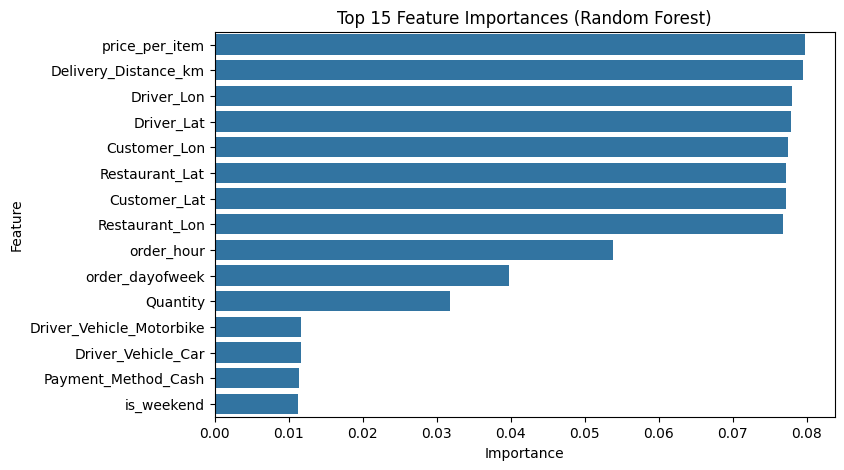

In [23]:
plt.figure(figsize=(8,5))

top_n = 15

sns.barplot(data=fi.head(top_n), x="importance", y="feature")

plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance chart shows which features had the strongest effect on predicting Order_Status. Features with higher importance values contributed more to the model.